# Prophet model by Meta used for time series analysis

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# Path of the dataset
data_path = '../data/DailyDelhiClimate.csv'

df = pd.read_csv(data_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1576 entries, 0 to 1575
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1576 non-null   str    
 1   meantemp      1576 non-null   float64
 2   humidity      1576 non-null   float64
 3   wind_speed    1576 non-null   float64
 4   meanpressure  1576 non-null   float64
dtypes: float64(4), str(1)
memory usage: 61.7 KB


In [3]:
# import the dataset
df = pd.read_csv(data_path, index_col="date", parse_dates=True)
print(df.head())
print(df.tail())

             meantemp   humidity  wind_speed  meanpressure
date                                                      
2013-01-01  10.000000  84.500000    0.000000   1015.666667
2013-01-02   7.400000  92.000000    2.980000   1017.800000
2013-01-03   7.166667  87.000000    4.633333   1018.666667
2013-01-04   8.666667  71.333333    1.233333   1017.166667
2013-01-05   6.000000  86.833333    3.700000   1016.500000
            meantemp   humidity  wind_speed  meanpressure
date                                                     
2017-04-20    34.500  27.500000    5.562500    998.625000
2017-04-21    34.250  39.375000    6.962500    999.875000
2017-04-22    32.900  40.900000    8.890000   1001.600000
2017-04-23    32.875  27.500000    9.962500   1002.125000
2017-04-24    32.000  27.142857   12.157143   1004.142857


In [4]:
df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1576.000000,1576.000000,1576.000000,1576.000000
mean,25.221918,60.445229,6.899262,1010.593178
std,7.345014,16.979994,4.510725,175.242704
min,6.000000,13.428571,0.000000,-3.041667
25%,18.500000,49.750000,3.700000,1001.875000
50%,27.166667,62.440476,6.363571,1009.055556
75%,31.142857,72.125000,9.262500,1015.200000
max,38.714286,100.000000,42.220000,7679.333333


<Axes: xlabel='date', ylabel='meantemp'>

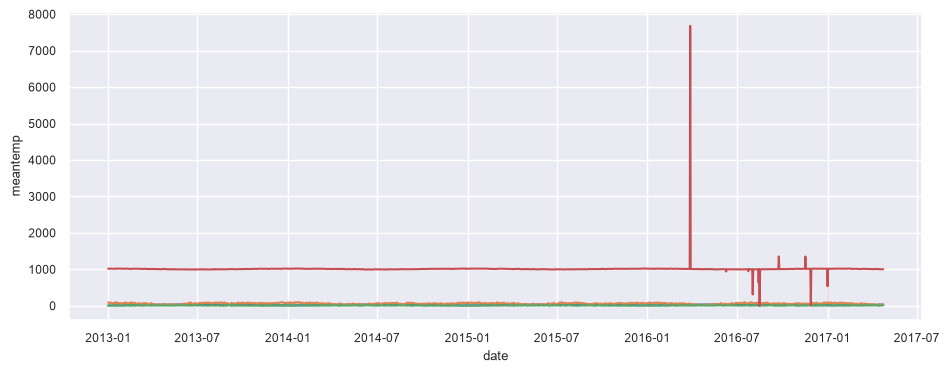

In [5]:
# draw a line plot
sns.set(rc={'figure.figsize':(11, 4)}, font_scale=0.8, style='darkgrid')
sns.lineplot(data=df, x="date", y="meantemp")
sns.lineplot(data=df, x="date", y="humidity")
sns.lineplot(data=df, x="date", y="wind_speed")
sns.lineplot(data=df, x="date", y="meanpressure")

In [6]:
# draw same plot on plotly
fig = px.line(df, x=df.index, y="meanpressure", title='Mean Pressure')
fig.show()

In [7]:
# interpolate the outliers from mean pressure column on 28.March.2016
df.loc['2016-03-28', 'meanpressure'] = np.nan
df['meanpressure'] = df['meanpressure'].interpolate(method='time')
df.loc['2016-03-28']

meantemp          25.933333
humidity          52.800000
wind_speed         6.546667
meanpressure    1012.062500
Name: 2016-03-28 00:00:00, dtype: float64

In [8]:
# make a scatter plot b/w meanteamp and humidity
fig = px.scatter(df, x="meantemp", y="humidity", title='Mean Temperature vs Humidity',
                 trendline="ols", trendline_color_override="red")
fig.show()

In [9]:
from scipy.stats import pearsonr
corr, _ = pearsonr(df['meantemp'], df['humidity'])
print('Pearsons correlation: %.3f' % corr)

Pearsons correlation: -0.575


<Axes: >

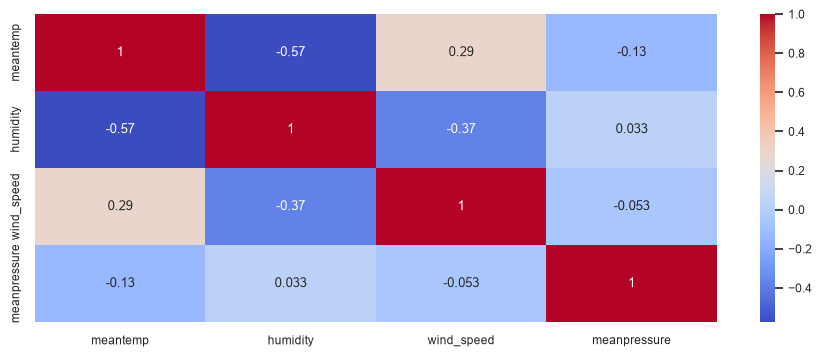

In [10]:
# make a heatmap of correlation
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [11]:
# lets scale the data
from sklearn.preprocessing import MinMaxScaler,StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
df_scaled.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1.576000e+03,1.576000e+03,1.576000e+03,1.576000e+03
mean,-1.893578e-16,-3.606816e-16,-1.397641e-16,-5.770905e-16
std,1.000317e+00,1.000317e+00,1.000317e+00,1.000317e+00
min,-2.617833e+00,-2.769823e+00,-1.530010e+00,-2.037522e+01
25%,-9.154579e-01,-6.300723e-01,-7.094819e-01,-9.058550e-02
50%,2.648553e-01,1.175431e-01,-1.187970e-01,5.435682e-02
75%,8.063727e-01,6.880732e-01,5.240817e-01,1.778802e-01
max,1.837525e+00,2.330232e+00,7.832877e+00,6.989246e+00


<Axes: >

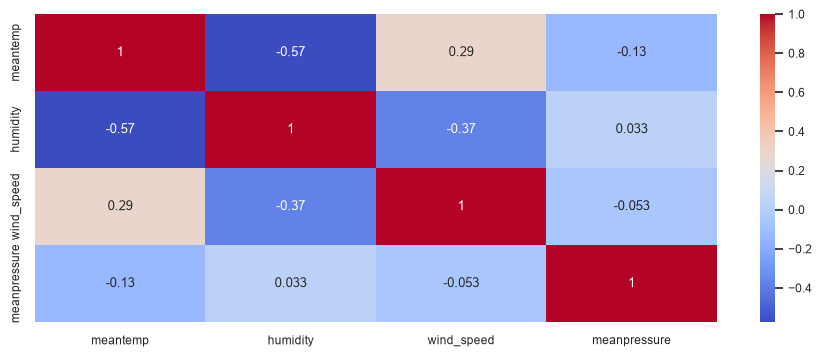

In [12]:
# make a correlation heatmap of scaled data
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm') # we wont see any change in correlation


<Axes: xlabel='date', ylabel='meantemp'>

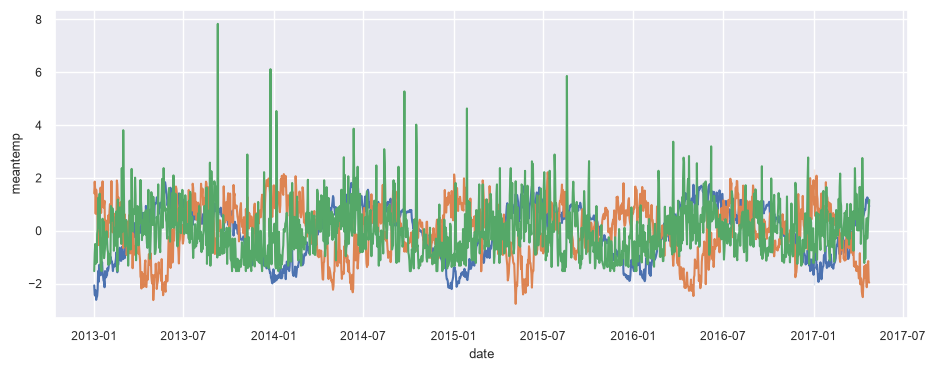

In [13]:
# draw a line plot
sns.set(rc={'figure.figsize':(11, 4)}, font_scale=0.8, style='darkgrid')
sns.lineplot(data=df_scaled, x="date", y="meantemp")
sns.lineplot(data=df_scaled, x="date", y="humidity")
sns.lineplot(data=df_scaled, x="date", y="wind_speed")
# sns.lineplot(data=df_scaled, x="date", y="meanpressure")

In [14]:
# add two columns in the dataset for month and year
df_scaled['month'] = df_scaled.index.month
df_scaled['year'] = df_scaled.index.year
df_scaled.head()

,meantemp,humidity,wind_speed,meanpressure,month,year
date,,,,,,
2013-01-01,-2.073073,1.417103,-1.530010,0.187805,1,2013
2013-01-02,-2.427167,1.858940,-0.869152,0.230867,1,2013
2013-01-03,-2.458944,1.564382,-0.502502,0.248361,1,2013
2013-01-04,-2.254659,0.641435,-1.256500,0.218083,1,2013
2013-01-05,-2.617833,1.554564,-0.709482,0.204626,1,2013


In [15]:
# add two columns in the dataset for month and year
df['month'] = df.index.month
df['year'] = df.index.year
df.head()

,meantemp,humidity,wind_speed,meanpressure,month,year
date,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,1,2013
2013-01-02,7.400000,92.000000,2.980000,1017.800000,1,2013
2013-01-03,7.166667,87.000000,4.633333,1018.666667,1,2013
2013-01-04,8.666667,71.333333,1.233333,1017.166667,1,2013
2013-01-05,6.000000,86.833333,3.700000,1016.500000,1,2013


(1.0, 12.0)

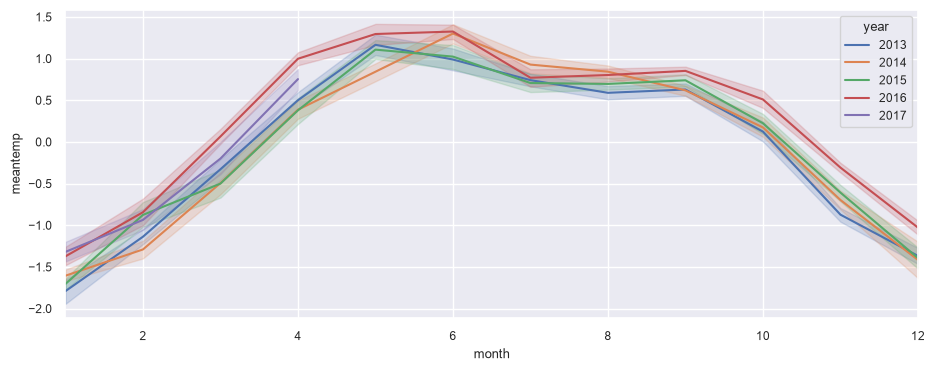

In [16]:
sns.lineplot(data=df_scaled, x="month", y="meantemp", hue="year", palette="deep")
plt.xlim(1, 12)

In [17]:
# same in plotly
fig = px.line(df_scaled, x=df_scaled.index , y="meantemp", color="year", title='Mean Temperature by Month')
fig.show()

In [18]:
# same in plotly
fig = px.line(df, x=df.index , y="meantemp", color="year", title='Mean Temperature by Month')
fig.show()

# lets use the prophet model from python

In [19]:
df = pd.read_csv(data_path)
df.info()

# rename the columns
df = df.rename(columns={'date':'ds', 'meantemp': 'y'})
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1576 entries, 0 to 1575
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1576 non-null   str    
 1   meantemp      1576 non-null   float64
 2   humidity      1576 non-null   float64
 3   wind_speed    1576 non-null   float64
 4   meanpressure  1576 non-null   float64
dtypes: float64(4), str(1)
memory usage: 61.7 KB


,ds,y,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [20]:
print(df)

              ds          y   humidity  wind_speed  meanpressure
0     2013-01-01  10.000000  84.500000    0.000000   1015.666667
1     2013-01-02   7.400000  92.000000    2.980000   1017.800000
2     2013-01-03   7.166667  87.000000    4.633333   1018.666667
3     2013-01-04   8.666667  71.333333    1.233333   1017.166667
4     2013-01-05   6.000000  86.833333    3.700000   1016.500000
...          ...        ...        ...         ...           ...
1571  2017-04-20  34.500000  27.500000    5.562500    998.625000
1572  2017-04-21  34.250000  39.375000    6.962500    999.875000
1573  2017-04-22  32.900000  40.900000    8.890000   1001.600000
1574  2017-04-23  32.875000  27.500000    9.962500   1002.125000
1575  2017-04-24  32.000000  27.142857   12.157143   1004.142857

[1576 rows x 5 columns]


In [21]:
from prophet import Prophet
from prophet.plot import plot_plotly
import pandas as pd

# Call and fit the model
model = Prophet()
model.fit(df)

future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

# --- ADVANCED MONKEY PATCH FOR THE PANDAS/PROPHET BUG ---
class TruthfulDataFrame(pd.DataFrame):
    def __bool__(self): return True

class TruthfulSeries(pd.Series):
    def __bool__(self): return True

# Wrap both attributes so 'assert' evaluations pass as True
patched_history = TruthfulDataFrame(model.history)
patched_changepoints = TruthfulSeries(model.changepoints)

# Temporarily inject the patched objects
_orig_hist = model.history
_orig_cp = model.changepoints
model.history = patched_history
model.changepoints = patched_changepoints

# Plot using model and forecast
fig = plot_plotly(model, forecast)

# Clean up and restore original attributes safely right after
model.history = _orig_hist
model.changepoints = _orig_cp

fig.show()


18:47:57 - cmdstanpy - INFO - Chain [1] start processing
18:47:58 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,24.665224,9.256500,14.254117,24.665224,24.665224,-12.746389,-12.746389,-12.746389,0.033591,0.033591,0.033591,-12.779980,-12.779980,-12.779980,0.0,0.0,0.0,11.918835
1,2013-01-02,24.665658,9.444594,14.640176,24.665658,24.665658,-12.605666,-12.605666,-12.605666,0.149794,0.149794,0.149794,-12.755460,-12.755460,-12.755460,0.0,0.0,0.0,12.059991
2,2013-01-03,24.666091,9.490145,14.554347,24.666091,24.666091,-12.625368,-12.625368,-12.625368,0.091760,0.091760,0.091760,-12.717128,-12.717128,-12.717128,0.0,0.0,0.0,12.040724
3,2013-01-04,24.666525,9.364371,14.579256,24.666525,24.666525,-12.649593,-12.649593,-12.649593,0.017513,0.017513,0.017513,-12.667106,-12.667106,-12.667106,0.0,0.0,0.0,12.016932
4,2013-01-05,24.666959,9.296563,14.538951,24.666959,24.666959,-12.713921,-12.713921,-12.713921,-0.106375,-0.106375,-0.106375,-12.607545,-12.607545,-12.607545,0.0,0.0,0.0,11.953038


In [23]:
# diagnose model fit on the training data
from sklearn.metrics import mean_absolute_error, mean_squared_error
y_true = df['y']
y_pred = forecast['yhat'][:len(df)]
print("MAE: ", mean_absolute_error(y_true, y_pred))
print("MSE: ", mean_squared_error(y_true, y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_true, y_pred)))


MAE:  1.6338681280479286
MSE:  4.288760924096654
RMSE:  2.0709323803776534


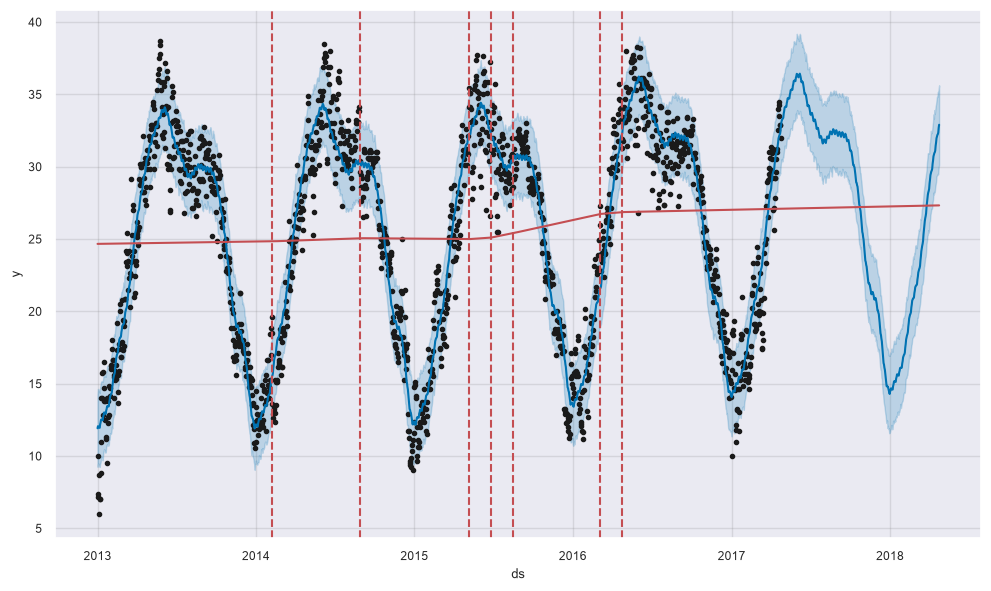

In [24]:
from prophet.plot import add_changepoints_to_plot

# plot model fitness on training data set and validation data set
fig = model.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), model, forecast)


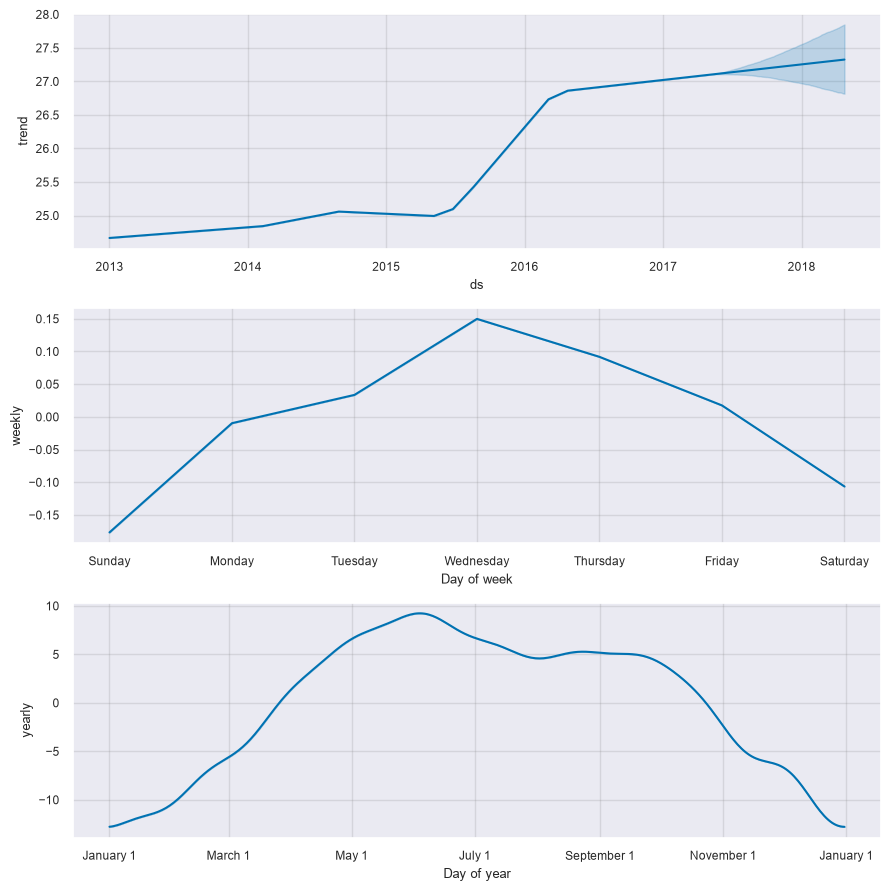

In [25]:
# plot model components
fig = model.plot_components(forecast)

18:49:11 - cmdstanpy - INFO - Chain [1] start processing
18:49:11 - cmdstanpy - INFO - Chain [1] done processing


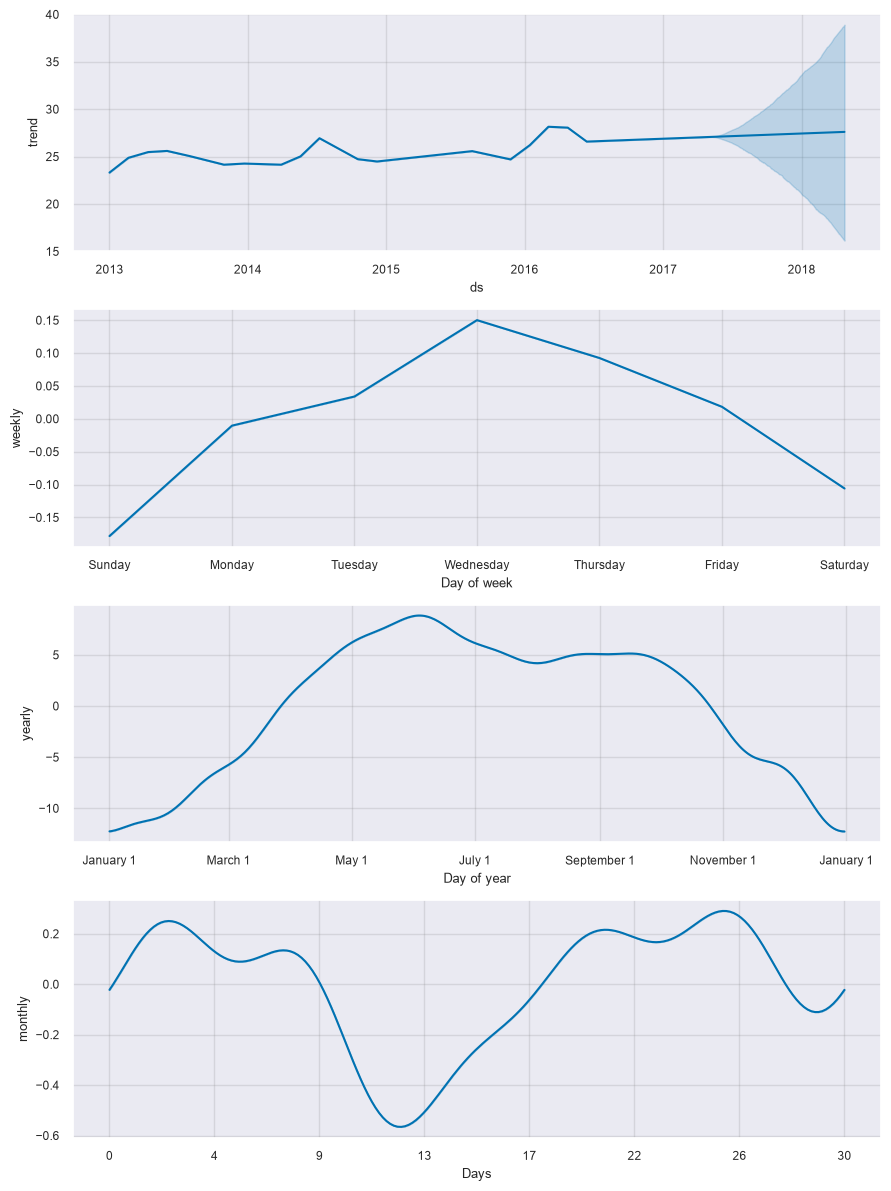

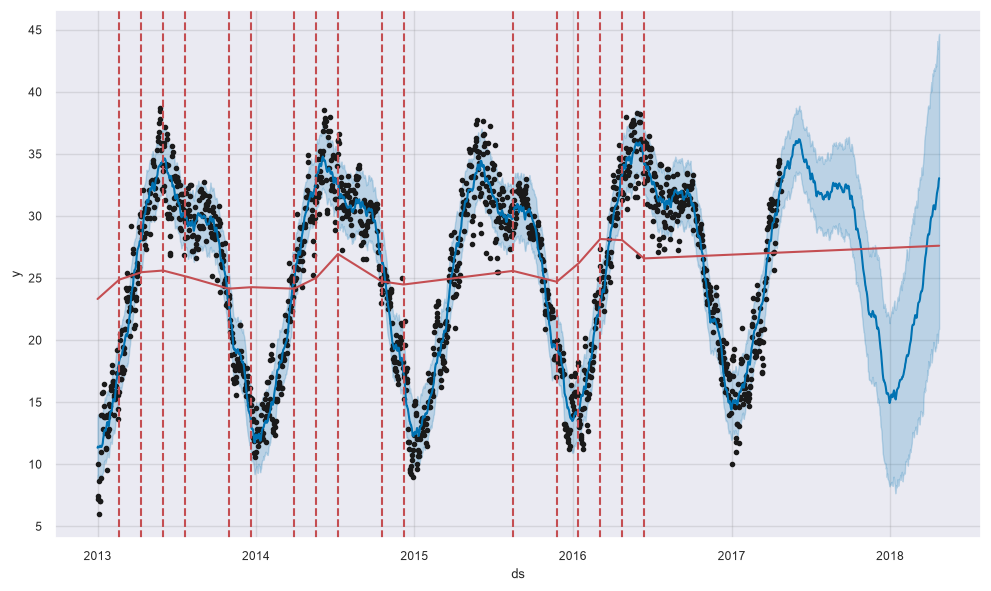

In [26]:
# model more components
model = Prophet(changepoint_prior_scale=0.5, seasonality_prior_scale=0.1, holidays_prior_scale=0.1)
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
model.fit(df)
forecast = model.make_future_dataframe(periods=365)
forecast = model.predict(forecast)
fig = model.plot_components(forecast)

# plot model fitness on training data set and validation data set
fig = model.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), model, forecast)


# # interpret the output
# from prophet.diagnostics import cross_validation
# df_cv = cross_validation(model, initial='730 days', period='180 days', horizon = '365 days')
# df_cv.head()